In [2]:
pip install -r "requirements.txt"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import dependencies

In [1]:
import pandas as pd
import numpy as np

# Data

## Load resale data

In [37]:
resale = pd.read_csv("Data/Resale_with_Coords.csv")

In [38]:
print(f"Shape: {resale.shape}")
print(resale.info())
resale.describe(include='all').T

Shape: (225127, 14)
<class 'pandas.DataFrame'>
RangeIndex: 225127 entries, 0 to 225126
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                225127 non-null  str    
 1   town                 225127 non-null  str    
 2   flat_type            225127 non-null  str    
 3   block                225127 non-null  str    
 4   street_name          225127 non-null  str    
 5   storey_range         225127 non-null  str    
 6   floor_area_sqm       225127 non-null  float64
 7   flat_model           225127 non-null  str    
 8   lease_commence_date  225127 non-null  int64  
 9   remaining_lease      225127 non-null  str    
 10  resale_price         225127 non-null  float64
 11  address              225127 non-null  str    
 12  latitude             225127 non-null  float64
 13  longitude            225127 non-null  float64
dtypes: float64(4), int64(1), str(9)
memory usage: 24.0 MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,225127,110,2024-07,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
town,225127,26,SENGKANG,18391,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_type,225127,7,4 ROOM,95464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,225127,2749,2,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,225127,577,YISHUN RING RD,3208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storey_range,225127,17,04 TO 06,51639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqm,225127.0,NaN,NaN,NaN,96.751932,24.019493,31.0,81.0,93.0,112.0,366.7
flat_model,225127,21,Model A,80573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lease_commence_date,225127.0,NaN,NaN,NaN,1996.463969,14.314362,1966.0,1985.0,1997.0,2012.0,2021.0
remaining_lease,225127,696,94 years 10 months,1919,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Data Check [None]

In [39]:
pd.DataFrame({
    'nunique': resale.nunique(dropna=False),
    'missing': resale.isna().sum(),
}).sort_values('nunique', ascending=False)

,nunique,missing
address,9684,0
latitude,9683,0
longitude,9683,0
resale_price,4590,0
block,2749,0
remaining_lease,696,0
street_name,577,0
floor_area_sqm,187,0
month,110,0
lease_commence_date,56,0


In [40]:
resale=resale.dropna()

## Data Description

In [41]:
# 'role': 'feature', 'target', 'identifier', 'metadata', 'ambiguous'
# 'type':  'num-cont', 'num-disc', 'cat-nom', 'cat-ord', 'bool'
role_map = {
    "month" : "feature",
    "town": "feature",
    "flat_type": "feature",
    "block": "identifier",
    "street_name": "identifier",
    "storey_range": "feature",
    "floor_area_sqm": "feature",
    "flat_model": "metadata",
    "lease_commence_date": "metadata",
    "remaining_lease": "feature",
    "resale_price": "target"
}
type_map = {
    "month" : "num-disc",
    "town": "cat-nom",
    "flat_type": "cat-nom",
    "block": "cat-nom",
    "street_name": "cat-nom",
    "storey_range": "cat-ord",
    "floor_area_sqm": "num-disc",
    "flat_model": "cat-nom",
    "lease_commence_date": "num-disc",
    "remaining_lease": "num-disc",
    "resale_price": "num-disc"
}

data_description = pd.DataFrame({
    "column": resale.columns,
})
data_description["role"] = data_description["column"].map(role_map).fillna("unknown")
data_description["type"] = data_description["column"].map(type_map).fillna("unknown")
data_description

,column,role,type
0,month,feature,num-disc
1,town,feature,cat-nom
2,flat_type,feature,cat-nom
3,block,identifier,cat-nom
4,street_name,identifier,cat-nom
5,storey_range,feature,cat-ord
6,floor_area_sqm,feature,num-disc
7,flat_model,metadata,cat-nom
8,lease_commence_date,metadata,num-disc
9,remaining_lease,feature,num-disc


## Data Pre-Processing

### Model Dataset Descriptions

In [42]:
model_data_desc = data_description[data_description['role'] != "metadata"]
model_data_desc

,column,role,type
0,month,feature,num-disc
1,town,feature,cat-nom
2,flat_type,feature,cat-nom
3,block,identifier,cat-nom
4,street_name,identifier,cat-nom
5,storey_range,feature,cat-ord
6,floor_area_sqm,feature,num-disc
9,remaining_lease,feature,num-disc
10,resale_price,target,num-disc
11,address,unknown,unknown


### Model Dataset

In [43]:
model_data = resale[model_data_desc["column"]].copy()
model_data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,61 years 04 months,232000.0,406 ANG MO KIO AVE 10,1.362005,103.853880
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,60 years 07 months,250000.0,108 ANG MO KIO AVE 4,1.370966,103.838202
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,62 years 05 months,262000.0,602 ANG MO KIO AVE 5,1.380709,103.835368
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,62 years 01 month,265000.0,465 ANG MO KIO AVE 10,1.366201,103.857201
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,62 years 05 months,265000.0,601 ANG MO KIO AVE 5,1.381041,103.835132


### Data Transformation

**Month** \
Convert to indexing for model input, index represents the order for time-series models \
index starts from 2017-01 onwards \
Example:

| Month(before) | index(after) |
| ------ | ------ |
| 2017-01 | 0 |
| 2017-02 | 1 |

In [44]:
months = pd.to_datetime(model_data['month'], format='%Y-%m')
model_data['month'] = (
    months.dt.year * 12 + months.dt.month
)

model_data['month'] -= model_data['month'].min()
model_data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude
0,0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,61 years 04 months,232000.0,406 ANG MO KIO AVE 10,1.362005,103.853880
1,0,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,60 years 07 months,250000.0,108 ANG MO KIO AVE 4,1.370966,103.838202
2,0,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,62 years 05 months,262000.0,602 ANG MO KIO AVE 5,1.380709,103.835368
3,0,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,62 years 01 month,265000.0,465 ANG MO KIO AVE 10,1.366201,103.857201
4,0,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,62 years 05 months,265000.0,601 ANG MO KIO AVE 5,1.381041,103.835132


**remaining_lease [Months]** \
Convert remaining_lease to number of months instead of X years X months

In [45]:
remaining_yrs = model_data['remaining_lease'].str.extract(r'(\d+)\D+(?:(\d+)\D+)?').fillna(0).astype(int)
model_data['remaining_lease'] = remaining_yrs[0] * 12 + remaining_yrs[1]
model_data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude
0,0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,736,232000.0,406 ANG MO KIO AVE 10,1.362005,103.853880
1,0,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,727,250000.0,108 ANG MO KIO AVE 4,1.370966,103.838202
2,0,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,749,262000.0,602 ANG MO KIO AVE 5,1.380709,103.835368
3,0,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,745,265000.0,465 ANG MO KIO AVE 10,1.366201,103.857201
4,0,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,749,265000.0,601 ANG MO KIO AVE 5,1.381041,103.835132


**Storey type** \
Replace storey range with the storey type (lower, middle, upper)

In [46]:
avg_storey = model_data['storey_range'].str.split(" TO ", expand=True).astype(int).mean(axis=1)
model_data['storey_type'] = pd.cut(avg_storey, bins=[1,3, 7,99], labels=['lower','middle','upper'], right=False)
model_data = pd.get_dummies(model_data, columns=['storey_type'])
model_data.drop(columns=['storey_range'], inplace=True)
model_data.head()

,month,town,flat_type,block,street_name,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper
0,0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,44.0,736,232000.0,406 ANG MO KIO AVE 10,1.362005,103.853880,False,False,True
1,0,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,67.0,727,250000.0,108 ANG MO KIO AVE 4,1.370966,103.838202,True,False,False
2,0,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,67.0,749,262000.0,602 ANG MO KIO AVE 5,1.380709,103.835368,True,False,False
3,0,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,68.0,745,265000.0,465 ANG MO KIO AVE 10,1.366201,103.857201,False,True,False
4,0,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,67.0,749,265000.0,601 ANG MO KIO AVE 5,1.381041,103.835132,True,False,False


**Quarter index** \
Defines which quarter is the data in example 2 for 2017-04 to 2017-07

In [47]:
model_data['quarter'] = model_data['month'] // 3
model_data.tail()

,month,town,flat_type,block,street_name,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper,quarter
225122,108,YISHUN,EXECUTIVE,325,YISHUN CTRL,146.0,743,920000.0,325 YISHUN CTRL,1.429239,103.842146,False,True,False,36
225123,108,YISHUN,EXECUTIVE,360,YISHUN RING RD,142.0,739,865888.0,360 YISHUN RING RD,1.427737,103.845686,False,False,True,36
225124,108,YISHUN,EXECUTIVE,643,YISHUN ST 61,142.0,729,825000.0,643 YISHUN ST 61,1.421335,103.837437,False,False,True,36
225125,108,YISHUN,EXECUTIVE,643,YISHUN ST 61,146.0,728,788000.0,643 YISHUN ST 61,1.421335,103.837437,False,True,False,36
225126,109,YISHUN,EXECUTIVE,611,YISHUN ST 61,146.0,730,860088.0,611 YISHUN ST 61,1.420201,103.836153,False,True,False,36


**Resale Price Index [RPI]**

In [48]:
rpi = pd.read_csv('Data/2025-RPI.csv')
rpi = rpi[rpi['year'] >= 2017]
rpi['quarter'] = (rpi['year'] - 2017) * 4 + (rpi['quarter'] - 1)
rpi.drop(columns=['year'], inplace=True)
rpi.head()

,quarter,rpi
32,0,133.9
33,1,133.7
34,2,132.8
35,3,132.6
36,4,131.6


In [49]:
model_data = pd.merge(model_data, rpi, on='quarter',how='left')
model_data.head()

,month,town,flat_type,block,street_name,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper,quarter,rpi
0,0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,44.0,736,232000.0,406 ANG MO KIO AVE 10,1.362005,103.853880,False,False,True,0,133.9
1,0,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,67.0,727,250000.0,108 ANG MO KIO AVE 4,1.370966,103.838202,True,False,False,0,133.9
2,0,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,67.0,749,262000.0,602 ANG MO KIO AVE 5,1.380709,103.835368,True,False,False,0,133.9
3,0,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,68.0,745,265000.0,465 ANG MO KIO AVE 10,1.366201,103.857201,False,True,False,0,133.9
4,0,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,67.0,749,265000.0,601 ANG MO KIO AVE 5,1.381041,103.835132,True,False,False,0,133.9


**Adjusted Resale Price** \
Formula: Resale price / RPI

In [50]:
model_data['adjusted_resale'] = model_data['resale_price'] / (model_data['rpi'] / 100)
model_data.head()

,month,town,flat_type,block,street_name,floor_area_sqm,remaining_lease,resale_price,address,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper,quarter,rpi,adjusted_resale
0,0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,44.0,736,232000.0,406 ANG MO KIO AVE 10,1.362005,103.853880,False,False,True,0,133.9,173263.629574
1,0,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,67.0,727,250000.0,108 ANG MO KIO AVE 4,1.370966,103.838202,True,False,False,0,133.9,186706.497386
2,0,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,67.0,749,262000.0,602 ANG MO KIO AVE 5,1.380709,103.835368,True,False,False,0,133.9,195668.409261
3,0,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,68.0,745,265000.0,465 ANG MO KIO AVE 10,1.366201,103.857201,False,True,False,0,133.9,197908.887229
4,0,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,67.0,749,265000.0,601 ANG MO KIO AVE 5,1.381041,103.835132,True,False,False,0,133.9,197908.887229


**Remove unneccessary columns**

In [51]:
transformed = model_data.drop(columns=['block','street_name','quarter','address'])
transformed.head()

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper,rpi,adjusted_resale
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,True,133.9,173263.629574
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,False,133.9,186706.497386
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,False,133.9,195668.409261
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,False,133.9,197908.887229
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,False,133.9,197908.887229


# Feature Extraction

Add amenity count for the varies amenities (mrt,bus-stop, schools, etc..)

## Import Dependencies

In [52]:
import geopandas as gpd
from shapely.geometry import Point

## Load Data

In [53]:
mrt_df = pd.read_csv("Data/mrt_stations.csv")
schools_df = pd.read_csv("Data/schools.csv")
malls_df = pd.read_csv("Data/shopping_malls.csv")
bus_stop_df = pd.read_csv("Data/bus_stops.csv")
hawker_df = pd.read_csv("Data/hawker_centres.csv")
wet_market_df = pd.read_csv("Data/wet_markets.csv")

## Project Data on Point

In [54]:
mrt_gdf = gpd.GeoDataFrame(mrt_df, geometry=gpd.points_from_xy(mrt_df.long, mrt_df.lat), crs="EPSG:4326")
schools_gdf = gpd.GeoDataFrame(schools_df, geometry=gpd.points_from_xy(schools_df.long, schools_df.lat), crs="EPSG:4326")
malls_gdf = gpd.GeoDataFrame(malls_df, geometry=gpd.points_from_xy(malls_df.long, malls_df.lat), crs="EPSG:4326")
bus_stop_gdf = gpd.GeoDataFrame(bus_stop_df, geometry=gpd.points_from_xy(bus_stop_df.long, bus_stop_df.lat), crs="EPSG:4326")
hawker_gdf = gpd.GeoDataFrame(hawker_df, geometry=gpd.points_from_xy(hawker_df.long, hawker_df.lat), crs="EPSG:4326")
wet_market_gdf = gpd.GeoDataFrame(hawker_df, geometry=gpd.points_from_xy(hawker_df.long, hawker_df.lat), crs="EPSG:4326")

In [55]:
flat_gdf = gpd.GeoDataFrame(transformed, geometry=gpd.points_from_xy(transformed.longitude, transformed.latitude), crs="EPSG:4326")
flat_gdf.head()

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper,rpi,adjusted_resale,geometry
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,True,133.9,173263.629574,POINT (103.85388 1.362)
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,False,133.9,186706.497386,POINT (103.8382 1.37097)
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,False,133.9,195668.409261,POINT (103.83537 1.38071)
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,False,133.9,197908.887229,POINT (103.8572 1.3662)
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,False,133.9,197908.887229,POINT (103.83513 1.38104)


In [56]:
# Reproject to a Metric CRS (Singapore SVY21 is EPSG:3414)
flat_gdf = flat_gdf.to_crs(epsg=3414)
mrt_gdf = mrt_gdf.to_crs(epsg=3414)
schools_gdf = schools_gdf.to_crs(epsg=3414)
malls_gdf = malls_gdf.to_crs(epsg=3414)
bus_stop_gdf = bus_stop_gdf.to_crs(epsg=3414)
hawker_gdf = hawker_gdf.to_crs(epsg=3414)
wet_market_gdf = wet_market_gdf.to_crs(epsg=3414)

## Create Buffer zone

In [57]:
# Create a 500m buffer around each house
flat_gdf['geometry'] = flat_gdf.geometry.buffer(500)

## Get Nearby amenties in radius (500M) (New Feature columns)

In [58]:
# Spatial Join: Count MRT stations inside the house buffers
joined = gpd.sjoin(flat_gdf, mrt_gdf, how="left", predicate="intersects")
school_joined = gpd.sjoin(flat_gdf, schools_gdf, how="left", predicate="intersects")
mall_joined = gpd.sjoin(flat_gdf, malls_gdf, how="left", predicate="intersects")
bus_stop_joined = gpd.sjoin(flat_gdf, bus_stop_gdf, how="left", predicate="intersects")
hawker_joined = gpd.sjoin(flat_gdf, hawker_gdf, how="left", predicate="intersects")
wet_market_joined = gpd.sjoin(flat_gdf, wet_market_gdf, how="left", predicate="intersects")

mrt_counts = joined.groupby(joined.index).size() - joined['index_right'].isna().groupby(joined.index).sum()
school_counts = school_joined.groupby(school_joined.index).size() - school_joined['index_right'].isna().groupby(school_joined.index).sum()
mall_counts = mall_joined.groupby(mall_joined.index).size() - mall_joined['index_right'].isna().groupby(mall_joined.index).sum()
bus_stop_counts = bus_stop_joined.groupby(bus_stop_joined.index).size() - bus_stop_joined['index_right'].isna().groupby(bus_stop_joined.index).sum()
hawker_counts = hawker_joined.groupby(hawker_joined.index).size() - hawker_joined['index_right'].isna().groupby(hawker_joined.index).sum()
wet_market_counts = wet_market_joined.groupby(wet_market_joined.index).size() - wet_market_joined['index_right'].isna().groupby(wet_market_joined.index).sum()

transformed['mrt_count'] = mrt_counts.values
transformed['school_count'] = school_counts.values
transformed['mall_count'] = mall_counts.values
transformed['bus_stop_count'] = bus_stop_counts.values
transformed['hawker_count'] = hawker_counts.values
transformed['wet_market_count'] = wet_market_counts.values
transformed.head()

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,storey_type_upper,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,True,133.9,173263.629574,0,3,0,14,1,1
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,False,133.9,186706.497386,1,2,0,11,1,1
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,False,133.9,195668.409261,1,0,0,12,0,0
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,False,133.9,197908.887229,0,1,0,10,2,2
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,False,133.9,197908.887229,1,0,0,11,0,0


## Calculate distance to nearest bus-stop and MRT station in meters (New Feature Columns)

In [59]:
# Create GeoDataFrame from transformed data
flat_point_gdf = gpd.GeoDataFrame(
    transformed, 
    geometry=gpd.points_from_xy(transformed.longitude, transformed.latitude), 
    crs="EPSG:4326"
)
flat_point_gdf = flat_point_gdf.to_crs(epsg=3414)
print("✓ flat_point_gdf created and reprojected.")

# --- Calculate Distance to Nearest MRT ---
print("Calculating nearest MRT distances...")
mrt_distances = []

for idx, flat in flat_point_gdf.iterrows():
    distances_to_all_mrt = mrt_gdf.geometry.distance(flat.geometry)
    min_distance = distances_to_all_mrt.min()
    mrt_distances.append(min_distance)

transformed['nearest_mrt_dist'] = pd.Series(mrt_distances).round(0).astype(int)
print(f"✓ Nearest MRT distance calculated for {len(mrt_distances)} flats.")

# --- Calculate Distance to Nearest Bus Stop ---
print("Calculating nearest bus stop distances...")
bus_distances = []

for idx, flat in flat_point_gdf.iterrows():
    distances_to_all_bus = bus_stop_gdf.geometry.distance(flat.geometry)
    min_distance = distances_to_all_bus.min()
    bus_distances.append(min_distance)

transformed['nearest_bus_stop_dist'] = pd.Series(bus_distances).round(0).astype(int)
print(f"✓ Nearest bus stop distance calculated for {len(bus_distances)} flats.")

# --- Validation ---
print(f"\nValidation:")
print(f"  MRT - NaN values: {transformed['nearest_mrt_dist'].isna().sum()}")
print(f"  Bus - NaN values: {transformed['nearest_bus_stop_dist'].isna().sum()}")
print(f"  MRT - Mean distance: {transformed['nearest_mrt_dist'].mean():.0f}m")
print(f"  Bus - Mean distance: {transformed['nearest_bus_stop_dist'].mean():.0f}m")

display(transformed.head())

✓ flat_point_gdf created and reprojected.
Calculating nearest MRT distances...
✓ Nearest MRT distance calculated for 225127 flats.
Calculating nearest bus stop distances...
✓ Nearest bus stop distance calculated for 225127 flats.

Validation:
  MRT - NaN values: 0
  Bus - NaN values: 0
  MRT - Mean distance: 565m
  Bus - Mean distance: 113m


,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,1,1016,91
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,1,202,164
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,460,136
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,2,828,68
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,433,146


In [61]:
import numpy as np

transformed['nearest_mrt_dist'] = np.floor(transformed['nearest_mrt_dist'])
transformed['nearest_bus_stop_dist'] = np.floor(transformed['nearest_bus_stop_dist'])

display(transformed.head())

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,1,1016,91
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,1,202,164
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,460,136
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,2,828,68
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,433,146


The `nearest_mrt_dist` and `nearest_bus_stop_dist` columns have now been rounded down to the nearest whole number. You can see the updated values in the displayed DataFrame.

# Export Data

In [62]:
transformed.to_csv('Data/processed.csv', index=False)

# Importing Data

### Data Understanding

In [8]:
resale = pd.read_csv("Data/processed.csv")
resale_extreme = resale[resale['floor_area_sqm'] > 350]  # drop the extreme outlier

summary = resale.groupby('flat_type').agg(
    Avg_Floor_Area=('floor_area_sqm', 'mean'),
    Avg_Resale_Price=('resale_price', 'mean'),
    Avg_Adjusted_Resale=('adjusted_resale', 'mean'),
    Count=('resale_price', 'count')
).round(2).sort_values('Avg_Floor_Area')

summary['Avg_Resale_Price'] = summary['Avg_Resale_Price'].apply(lambda x: f'${x:,.0f}')
summary['Avg_Adjusted_Resale'] = summary['Avg_Adjusted_Resale'].apply(lambda x: f'${x:,.0f}')
summary['Avg_Floor_Area'] = summary['Avg_Floor_Area'].apply(lambda x: f'{x:.1f} sqm')
display(summary)

,Avg_Floor_Area,Avg_Resale_Price,Avg_Adjusted_Resale,Count
flat_type,,,,
1 ROOM,31.0 sqm,"$211,987","$137,326",82
2 ROOM,45.7 sqm,"$301,466","$178,969",4586
3 ROOM,68.2 sqm,"$373,075","$233,229",53591
4 ROOM,95.0 sqm,"$530,607","$331,233",95464
5 ROOM,117.7 sqm,"$625,558","$395,737",55179
EXECUTIVE,144.8 sqm,"$733,328","$469,714",16140
MULTI-GENERATION,161.2 sqm,"$859,598","$576,660",85


In [9]:
resale_extreme

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
182828,90,KALLANG/WHAMPOA,3 ROOM,366.7,564,1568000.0,1.328279,103.856097,True,False,...,192.9,812856.402281,0,0,0,12,0,0,1106,221


## Feature Heatmap

## Feature Correlation observations (compared to adjusted resale)

## Outlier Analysis

In [10]:
display(resale[numeric_cols].describe().round(2))

NameError: name 'numeric_cols' is not defined

### IQR outlier detection

In [ ]:
outlier_summary = []
for col in numeric_cols:
    Q1 = resale[col].quantile(0.25)
    Q3 = resale[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = resale[(resale[col] < lower) | (resale[col] > upper)]
    pct = len(outliers) / len(resale) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(pct, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,month,31.00,83.00,52.00,-47.00,161.00,0,0.00
1,floor_area_sqm,81.00,112.00,31.00,34.50,158.50,1203,0.53
2,remaining_lease,749.00,1064.00,315.00,276.50,1536.50,0,0.00
3,resale_price,388000.00,630000.00,242000.00,25000.00,993000.00,4328,1.92
4,latitude,1.34,1.40,0.06,1.25,1.49,0,0.00
5,longitude,103.78,103.90,0.12,103.60,104.08,0,0.00
6,rpi,132.60,180.40,47.80,60.90,252.10,0,0.00
7,adjusted_resale,254365.98,385944.70,131578.72,56997.91,583312.78,6405,2.85
8,mrt_count,0.00,1.00,1.00,-1.50,2.50,4590,2.04
9,school_count,1.00,3.00,2.00,-2.00,6.00,2517,1.12


In [ ]:
print("FEATURE ANALYSIS RESULTS & INTERPRETATION")
print("="*80)

# Define target variable
target_col = 'adjusted_resale' if 'adjusted_resale' in resale.columns else 'resale_price'

# Get correlations with target
numeric_cols = resale.select_dtypes(include=[np.number]).columns
target_correlations = resale[numeric_cols].corr()[target_col].sort_values(ascending=False)

# Categorize features by correlation strength and type
feature_categories = {
    'Strong Predictors (|r| > 0.5)': [],
    'Moderate Predictors (0.3 < |r| < 0.5)': [],
    'Physical Characteristics': [],
    'Location Features': [],
    'Amenity Features (Count)': [],
    'Amenity Features (Distance)': [],
    'Redundant Features (To Drop)': [],
    'Low Variance Features (To Drop)': []
}

# Categorize each feature
for feature, corr in target_correlations.items():
    if feature == target_col:
        continue
    
    abs_corr = abs(corr)
    
    # Check for redundancy
    if feature in ['resale_price', 'rpi']:
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))
    elif feature == 'month':
        feature_categories['Low Variance Features (To Drop)'].append((feature, corr))
    elif feature == 'wet_market_count':
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))
    
    # Strong predictors
    elif abs_corr > 0.5:
        feature_categories['Strong Predictors (|r| > 0.5)'].append((feature, corr))
    
    # Moderate predictors
    elif abs_corr >= 0.3:
        feature_categories['Moderate Predictors (0.3 < |r| < 0.5)'].append((feature, corr))
    
    # Physical characteristics
    elif feature in ['floor_area_sqm', 'remaining_lease', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper']:
        feature_categories['Physical Characteristics'].append((feature, corr))
    
    # Location
    elif feature in ['latitude', 'longitude']:
        feature_categories['Location Features'].append((feature, corr))
    
    # Amenity counts
    elif 'count' in feature.lower():
        feature_categories['Amenity Features (Count)'].append((feature, corr))
    
    # Amenity distances
    elif 'dist' in feature.lower() or 'nearest' in feature.lower():
        feature_categories['Amenity Features (Distance)'].append((feature, corr))

# Display categorized features
print("\n" + "="*80)
print("FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH")
print("="*80)

for category, features in feature_categories.items():
    if features:
        print(f"\n{'─'*80}")
        print(f"{category}:")
        print(f"{'─'*80}")
        for feature, corr in features:
            print(f"  {feature:.<40} r = {corr:>6.3f}")

FEATURE ANALYSIS RESULTS & INTERPRETATION

FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH

────────────────────────────────────────────────────────────────────────────────
Strong Predictors (|r| > 0.5):
────────────────────────────────────────────────────────────────────────────────
  floor_area_sqm.......................... r =  0.651

────────────────────────────────────────────────────────────────────────────────
Moderate Predictors (0.3 < |r| < 0.5):
────────────────────────────────────────────────────────────────────────────────
  remaining_lease......................... r =  0.354

────────────────────────────────────────────────────────────────────────────────
Location Features:
────────────────────────────────────────────────────────────────────────────────
  longitude............................... r =  0.108
  latitude................................ r = -0.202

────────────────────────────────────────────────────────────────────────────────
Amenity Features (Count):
─

### Results Discussion

#### Columns to keep

##### Floor_area_sqm, Remaining_lease, latitude, Longitude, All amenities.

Floor_area_sqm and remaining_lease are the biggest impact based on the features and have been cross checked with experts in the field.

Lat,long itself might not seem like much but typically locations closer to the center of singapore would be priced higher, hence would be a factor

Although amenities itself has low correlation to the adjusted resale, they do have a real impact when asking experts in the field. It was suggested that the prices can vary by about 10% based on the amenities itself. While alone they might not amount to much together they might have a compounding effect which is why it is not wise to drop them.

#### Columns to drop

##### resale price, wet_market_count, rpi, month

resale price would be data leakage.
month is very similar to remaining lease, hence will be dropped, also because low correlation.
wet_market_count is too similar to hawker centers, unless we fix the 1:1 correlation, we drop one of them.
rpi is unnecessary for model training until the final multiplicative step.

## Scatterplot

## Feature Heatmap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load processed data
resale = pd.read_csv("Data/processed.csv")

print(resale.columns.tolist())

# Show first few rows
display(resale.head())

# Quick data info
print("\n" + "="*80)
print("DATA INFO")
print("="*80)
print(resale.info())


['month', 'town', 'flat_type', 'floor_area_sqm', 'remaining_lease', 'resale_price', 'latitude', 'longitude', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper', 'rpi', 'adjusted_resale', 'mrt_count', 'school_count', 'mall_count', 'bus_stop_count', 'hawker_count', 'wet_market_count', 'nearest_mrt_dist', 'nearest_bus_stop_dist']


,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,1,81.0,271.0
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,1,266.0,279.0
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,183.0,192.0
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,2,2680.0,4898.0
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,81.0,1748.0



DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 225127 entries, 0 to 225126
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   month                  225127 non-null  int64  
 1   town                   225127 non-null  str    
 2   flat_type              225127 non-null  str    
 3   floor_area_sqm         225127 non-null  float64
 4   remaining_lease        225127 non-null  int64  
 5   resale_price           225127 non-null  float64
 6   latitude               225127 non-null  float64
 7   longitude              225127 non-null  float64
 8   storey_type_lower      225127 non-null  bool   
 9   storey_type_middle     225127 non-null  bool   
 10  storey_type_upper      225127 non-null  bool   
 11  rpi                    222074 non-null  float64
 12  adjusted_resale        222074 non-null  float64
 13  mrt_count              225127 non-null  int64  
 14  school_count           225127 non-nu

Analyzing 16 numeric features



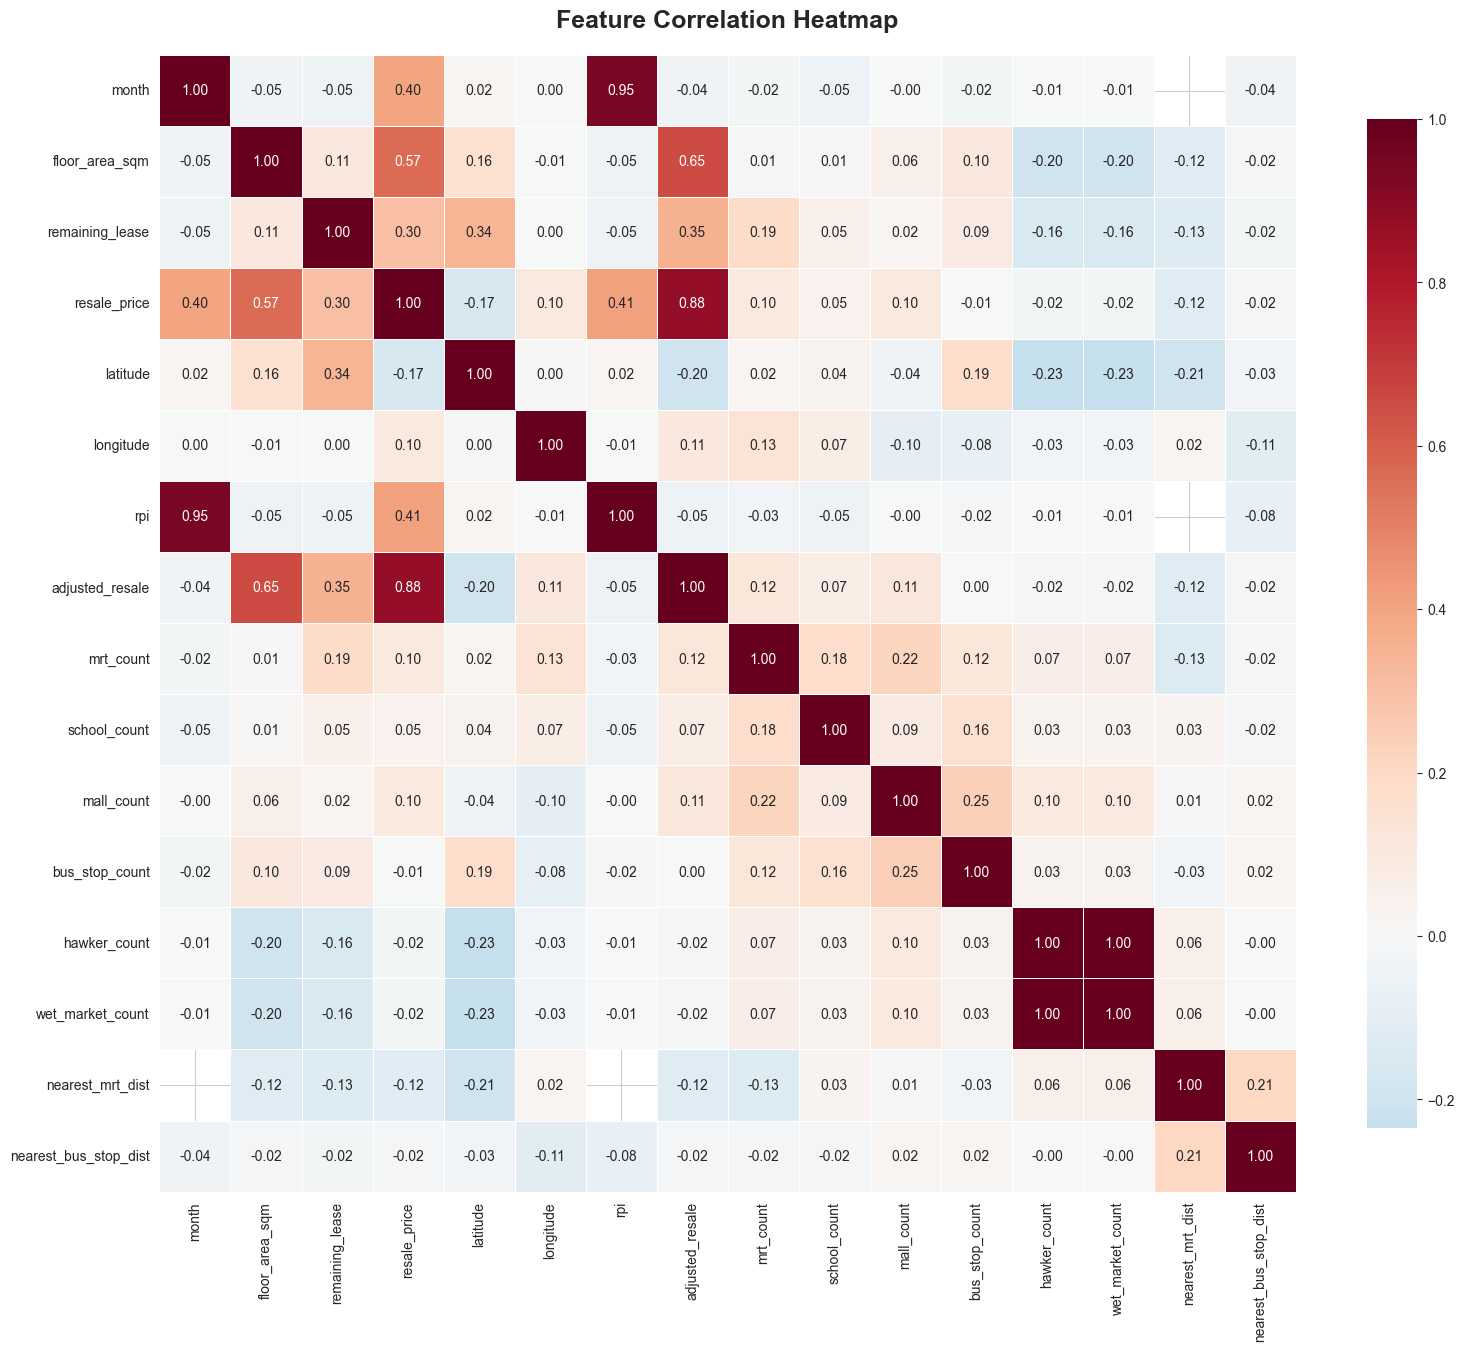

✓ Correlation heatmap generated


In [ ]:
# Get numeric columns only
numeric_cols = resale.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_cols)} numeric features\n")

# Calculate correlation matrix
correlation_matrix = resale[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap generated")

## Feature Correlation observations (compared to adjusted resale)

## Outlier Analysis

## Scatterplot

OUTLIER COUNT BY FLAT TYPE


,Total,Outliers,Outlier %
flat_type,,,
1 ROOM,80,2,2.50
2 ROOM,4496,125,2.78
3 ROOM,52875,3306,6.25
4 ROOM,94093,7724,8.21
5 ROOM,54510,3245,5.95
EXECUTIVE,15936,462,2.90
MULTI-GENERATION,84,0,0.00



Total outliers: 14,864 / 222,074 (6.69%)


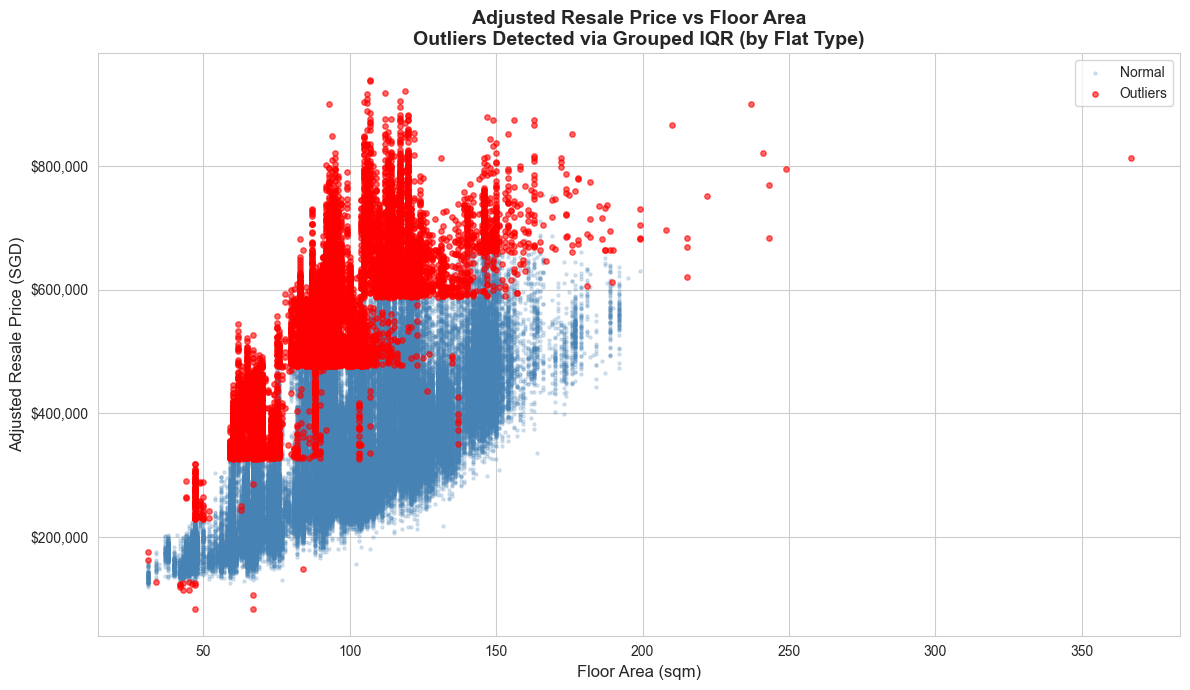

In [ ]:
# ------------------------------------------------------------
# IQR WITHIN GROUPS (by flat_type)
# ------------------------------------------------------------

plot_df = resale.dropna(subset=['adjusted_resale']).copy()

def flag_outliers_iqr(group, col, multiplier=1.5):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (group[col] < lower) | (group[col] > upper)

# Flag outliers within each flat_type group
plot_df['is_outlier'] = (
    plot_df.groupby('flat_type', group_keys=False)
    .apply(lambda g: flag_outliers_iqr(g, 'adjusted_resale'))
)

# Summary table
print("=" * 60)
print("OUTLIER COUNT BY FLAT TYPE")
print("=" * 60)
summary = plot_df.groupby('flat_type')['is_outlier'].agg(
    Total='count',
    Outliers='sum'
)
summary['Outlier %'] = (summary['Outliers'] / summary['Total'] * 100).round(2)
display(summary)

print(f"\nTotal outliers: {plot_df['is_outlier'].sum():,} / {len(plot_df):,} ({plot_df['is_outlier'].mean()*100:.2f}%)")

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(plot_df.loc[~plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[~plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.2, s=5, color='steelblue', label='Normal')

ax.scatter(plot_df.loc[plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.6, s=15, color='red', label='Outliers')

ax.set_xlabel('Floor Area (sqm)', fontsize=12)
ax.set_ylabel('Adjusted Resale Price (SGD)', fontsize=12)
ax.set_title('Adjusted Resale Price vs Floor Area\nOutliers Detected via Grouped IQR (by Flat Type)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
display(resale[resale['floor_area_sqm'] >= 350])

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
182828,90,KALLANG/WHAMPOA,3 ROOM,366.7,564,1568000.0,1.328279,103.856097,True,False,...,192.9,812856.402281,0,0,0,12,0,0,NaN,NaN


### Outlier discussion

We detect outliers by room types instead of one whole column because if we do by whole column, any price above a certain sqm will be flagged as outliers. For this graph we use interquartile range (25-75%) where anything above and below is outlier.
Here we can see it is more correct where certain extreme ends of data points are flagged out.
However, since these are actual datapoints. I suggest we only remove the extreme outliers. (E.g. from the graph above the one above 350 sqm)

In [ ]:
display(resale[numeric_cols].describe().round(2))

,month,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
count,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,222074.00,222074.00,225127.00,225127.00,225127.00,225127.00,225127.00,225127.00,221.00,5260.00
mean,56.90,96.75,890.66,526253.70,1.37,103.84,159.08,330609.14,0.65,2.23,0.55,15.58,0.45,0.45,536.56,704.40
std,30.58,24.02,170.96,187445.06,0.04,0.07,26.18,107981.99,0.78,1.41,0.84,4.55,0.67,0.67,790.85,1290.50
min,0.00,31.00,477.00,140000.00,1.27,103.69,130.80,83148.56,0.00,0.00,0.00,3.00,0.00,0.00,22.00,11.00
25%,31.00,81.00,749.00,388000.00,1.34,103.78,132.60,254365.98,0.00,1.00,0.00,12.00,0.00,0.00,78.00,59.00
50%,58.00,93.00,888.00,495000.00,1.37,103.85,155.70,313010.34,0.00,2.00,0.00,15.00,0.00,0.00,232.00,195.00
75%,83.00,112.00,1064.00,630000.00,1.40,103.90,180.40,385944.70,1.00,3.00,1.00,19.00,1.00,1.00,626.00,733.25
max,109.00,366.70,1173.00,1658888.00,1.46,103.99,203.70,939507.09,5.00,17.00,11.00,30.00,5.00,5.00,5393.00,10860.00


### IQR outlier detection

In [ ]:
outlier_summary = []
for col in numeric_cols:
    Q1 = resale[col].quantile(0.25)
    Q3 = resale[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = resale[(resale[col] < lower) | (resale[col] > upper)]
    pct = len(outliers) / len(resale) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(pct, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,month,31.00,83.00,52.00,-47.00,161.00,0,0.00
1,floor_area_sqm,81.00,112.00,31.00,34.50,158.50,1203,0.53
2,remaining_lease,749.00,1064.00,315.00,276.50,1536.50,0,0.00
3,resale_price,388000.00,630000.00,242000.00,25000.00,993000.00,4328,1.92
4,latitude,1.34,1.40,0.06,1.25,1.49,0,0.00
5,longitude,103.78,103.90,0.12,103.60,104.08,0,0.00
6,rpi,132.60,180.40,47.80,60.90,252.10,0,0.00
7,adjusted_resale,254365.98,385944.70,131578.72,56997.91,583312.78,6405,2.85
8,mrt_count,0.00,1.00,1.00,-1.50,2.50,4590,2.04
9,school_count,1.00,3.00,2.00,-2.00,6.00,2517,1.12


In [ ]:
print("FEATURE ANALYSIS RESULTS & INTERPRETATION")
print("="*80)

# Define target variable
target_col = 'adjusted_resale' if 'adjusted_resale' in resale.columns else 'resale_price'

# Get correlations with target
numeric_cols = resale.select_dtypes(include=[np.number]).columns
target_correlations = resale[numeric_cols].corr()[target_col].sort_values(ascending=False)

# Categorize features by correlation strength and type
feature_categories = {
    'Strong Predictors (|r| > 0.5)': [],
    'Moderate Predictors (0.3 < |r| < 0.5)': [],
    'Physical Characteristics': [],
    'Location Features': [],
    'Amenity Features (Count)': [],
    'Amenity Features (Distance)': [],
    'Redundant Features (To Drop)': [],
    'Low Variance Features (To Drop)': []
}

# Categorize each feature
for feature, corr in target_correlations.items():
    if feature == target_col:
        continue
    
    abs_corr = abs(corr)
    
    # Check for redundancy
    if feature in ['resale_price', 'rpi']:
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))
    elif feature == 'month':
        feature_categories['Low Variance Features (To Drop)'].append((feature, corr))
    elif feature == 'wet_market_count':
        feature_categories['Redundant Features (To Drop)'].append((feature, corr))
    
    # Strong predictors
    elif abs_corr > 0.5:
        feature_categories['Strong Predictors (|r| > 0.5)'].append((feature, corr))
    
    # Moderate predictors
    elif abs_corr >= 0.3:
        feature_categories['Moderate Predictors (0.3 < |r| < 0.5)'].append((feature, corr))
    
    # Physical characteristics
    elif feature in ['floor_area_sqm', 'remaining_lease', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper']:
        feature_categories['Physical Characteristics'].append((feature, corr))
    
    # Location
    elif feature in ['latitude', 'longitude']:
        feature_categories['Location Features'].append((feature, corr))
    
    # Amenity counts
    elif 'count' in feature.lower():
        feature_categories['Amenity Features (Count)'].append((feature, corr))
    
    # Amenity distances
    elif 'dist' in feature.lower() or 'nearest' in feature.lower():
        feature_categories['Amenity Features (Distance)'].append((feature, corr))

# Display categorized features
print("\n" + "="*80)
print("FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH")
print("="*80)

for category, features in feature_categories.items():
    if features:
        print(f"\n{'─'*80}")
        print(f"{category}:")
        print(f"{'─'*80}")
        for feature, corr in features:
            print(f"  {feature:.<40} r = {corr:>6.3f}")

FEATURE ANALYSIS RESULTS & INTERPRETATION

FEATURES CATEGORIZED BY TYPE AND CORRELATION STRENGTH

────────────────────────────────────────────────────────────────────────────────
Strong Predictors (|r| > 0.5):
────────────────────────────────────────────────────────────────────────────────
  floor_area_sqm.......................... r =  0.651

────────────────────────────────────────────────────────────────────────────────
Moderate Predictors (0.3 < |r| < 0.5):
────────────────────────────────────────────────────────────────────────────────
  remaining_lease......................... r =  0.354

────────────────────────────────────────────────────────────────────────────────
Location Features:
────────────────────────────────────────────────────────────────────────────────
  longitude............................... r =  0.108
  latitude................................ r = -0.202

────────────────────────────────────────────────────────────────────────────────
Amenity Features (Count):
─

### Results Discussion

#### Columns to keep

##### Floor_area_sqm, Remaining_lease, latitude, Longitude, All amenities.

Floor_area_sqm and remaining_lease are the biggest impact based on the features and have been cross checked with experts in the field.

Lat,long itself might not seem like much but typically locations closer to the center of singapore would be priced higher, hence would be a factor

Although amenities itself has low correlation to the adjusted resale, they do have a real impact when asking experts in the field. It was suggested that the prices can vary by about 10% based on the amenities itself. While alone they might not amount to much together they might have a compounding effect which is why it is not wise to drop them.

#### Columns to drop

##### resale price, wet_market_count, rpi, month

resale price would be data leakage.
month is very similar to remaining lease, hence will be dropped, also because low correlation.
wet_market_count is too similar to hawker centers, unless we fix the 1:1 correlation, we drop one of them.
rpi is unnecessary for model training until the final multiplicative step.

OUTLIER COUNT BY FLAT TYPE


,Total,Outliers,Outlier %
flat_type,,,
1 ROOM,80,2,2.50
2 ROOM,4496,125,2.78
3 ROOM,52875,3306,6.25
4 ROOM,94093,7724,8.21
5 ROOM,54510,3245,5.95
EXECUTIVE,15936,462,2.90
MULTI-GENERATION,84,0,0.00



Total outliers: 14,864 / 222,074 (6.69%)


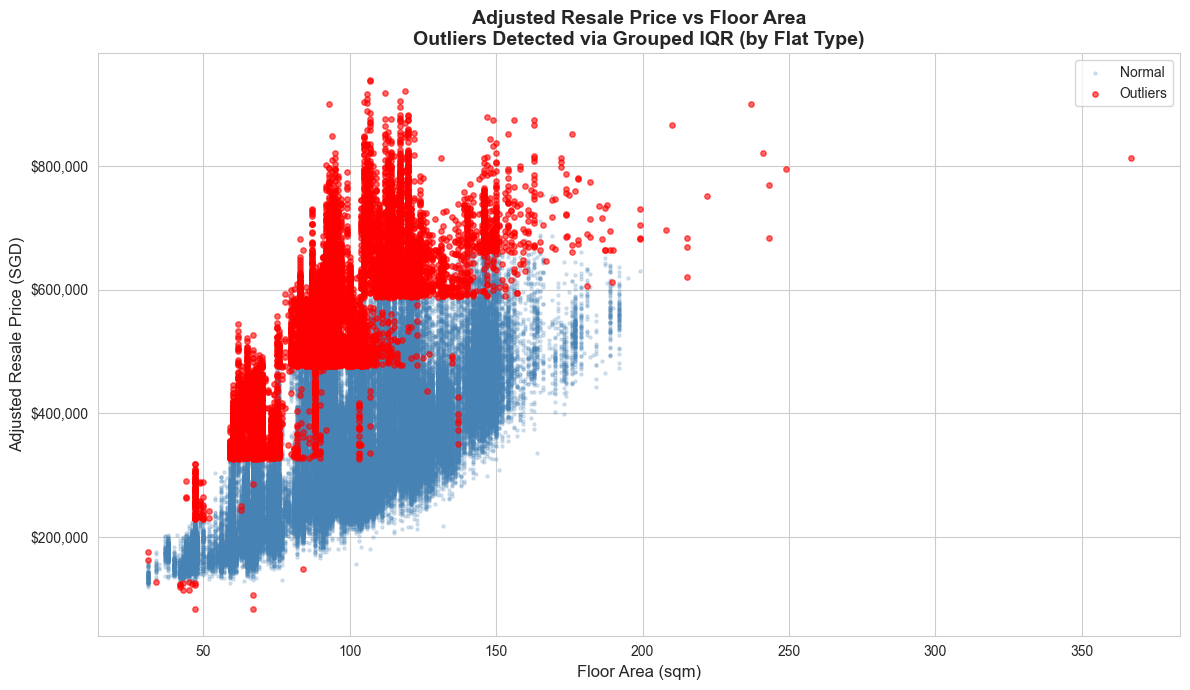

In [ ]:
# ------------------------------------------------------------
# IQR WITHIN GROUPS (by flat_type)
# ------------------------------------------------------------

plot_df = resale.dropna(subset=['adjusted_resale']).copy()

def flag_outliers_iqr(group, col, multiplier=1.5):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (group[col] < lower) | (group[col] > upper)

# Flag outliers within each flat_type group
plot_df['is_outlier'] = (
    plot_df.groupby('flat_type', group_keys=False)
    .apply(lambda g: flag_outliers_iqr(g, 'adjusted_resale'))
)

# Summary table
print("=" * 60)
print("OUTLIER COUNT BY FLAT TYPE")
print("=" * 60)
summary = plot_df.groupby('flat_type')['is_outlier'].agg(
    Total='count',
    Outliers='sum'
)
summary['Outlier %'] = (summary['Outliers'] / summary['Total'] * 100).round(2)
display(summary)

print(f"\nTotal outliers: {plot_df['is_outlier'].sum():,} / {len(plot_df):,} ({plot_df['is_outlier'].mean()*100:.2f}%)")

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(plot_df.loc[~plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[~plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.2, s=5, color='steelblue', label='Normal')

ax.scatter(plot_df.loc[plot_df['is_outlier'], 'floor_area_sqm'],
           plot_df.loc[plot_df['is_outlier'], 'adjusted_resale'],
           alpha=0.6, s=15, color='red', label='Outliers')

ax.set_xlabel('Floor Area (sqm)', fontsize=12)
ax.set_ylabel('Adjusted Resale Price (SGD)', fontsize=12)
ax.set_title('Adjusted Resale Price vs Floor Area\nOutliers Detected via Grouped IQR (by Flat Type)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
display(resale[resale['floor_area_sqm'] >= 350])

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
182828,90,KALLANG/WHAMPOA,3 ROOM,366.7,564,1568000.0,1.328279,103.856097,True,False,...,192.9,812856.402281,0,0,0,12,0,0,NaN,NaN


### Outlier discussion

We detect outliers by room types instead of one whole column because if we do by whole column, any price above a certain sqm will be flagged as outliers. For this graph we use interquartile range (25-75%) where anything above and below is outlier.
Here we can see it is more correct where certain extreme ends of data points are flagged out.
However, since these are actual datapoints. I suggest we only remove the extreme outliers. (E.g. from the graph above the one above 350 sqm)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load processed data
resale = pd.read_csv("Data/processed.csv")

print(resale.columns.tolist())

# Show first few rows
display(resale.head())

# Quick data info
print("\n" + "="*80)
print("DATA INFO")
print("="*80)
print(resale.info())


['month', 'town', 'flat_type', 'floor_area_sqm', 'remaining_lease', 'resale_price', 'latitude', 'longitude', 'storey_type_lower', 'storey_type_middle', 'storey_type_upper', 'rpi', 'adjusted_resale', 'mrt_count', 'school_count', 'mall_count', 'bus_stop_count', 'hawker_count', 'wet_market_count', 'nearest_mrt_dist', 'nearest_bus_stop_dist']


,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,1,81.0,271.0
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,1,266.0,279.0
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,183.0,192.0
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,2,2680.0,4898.0
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,81.0,1748.0



DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 225127 entries, 0 to 225126
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   month                  225127 non-null  int64  
 1   town                   225127 non-null  str    
 2   flat_type              225127 non-null  str    
 3   floor_area_sqm         225127 non-null  float64
 4   remaining_lease        225127 non-null  int64  
 5   resale_price           225127 non-null  float64
 6   latitude               225127 non-null  float64
 7   longitude              225127 non-null  float64
 8   storey_type_lower      225127 non-null  bool   
 9   storey_type_middle     225127 non-null  bool   
 10  storey_type_upper      225127 non-null  bool   
 11  rpi                    222074 non-null  float64
 12  adjusted_resale        222074 non-null  float64
 13  mrt_count              225127 non-null  int64  
 14  school_count           225127 non-nu

Analyzing 16 numeric features



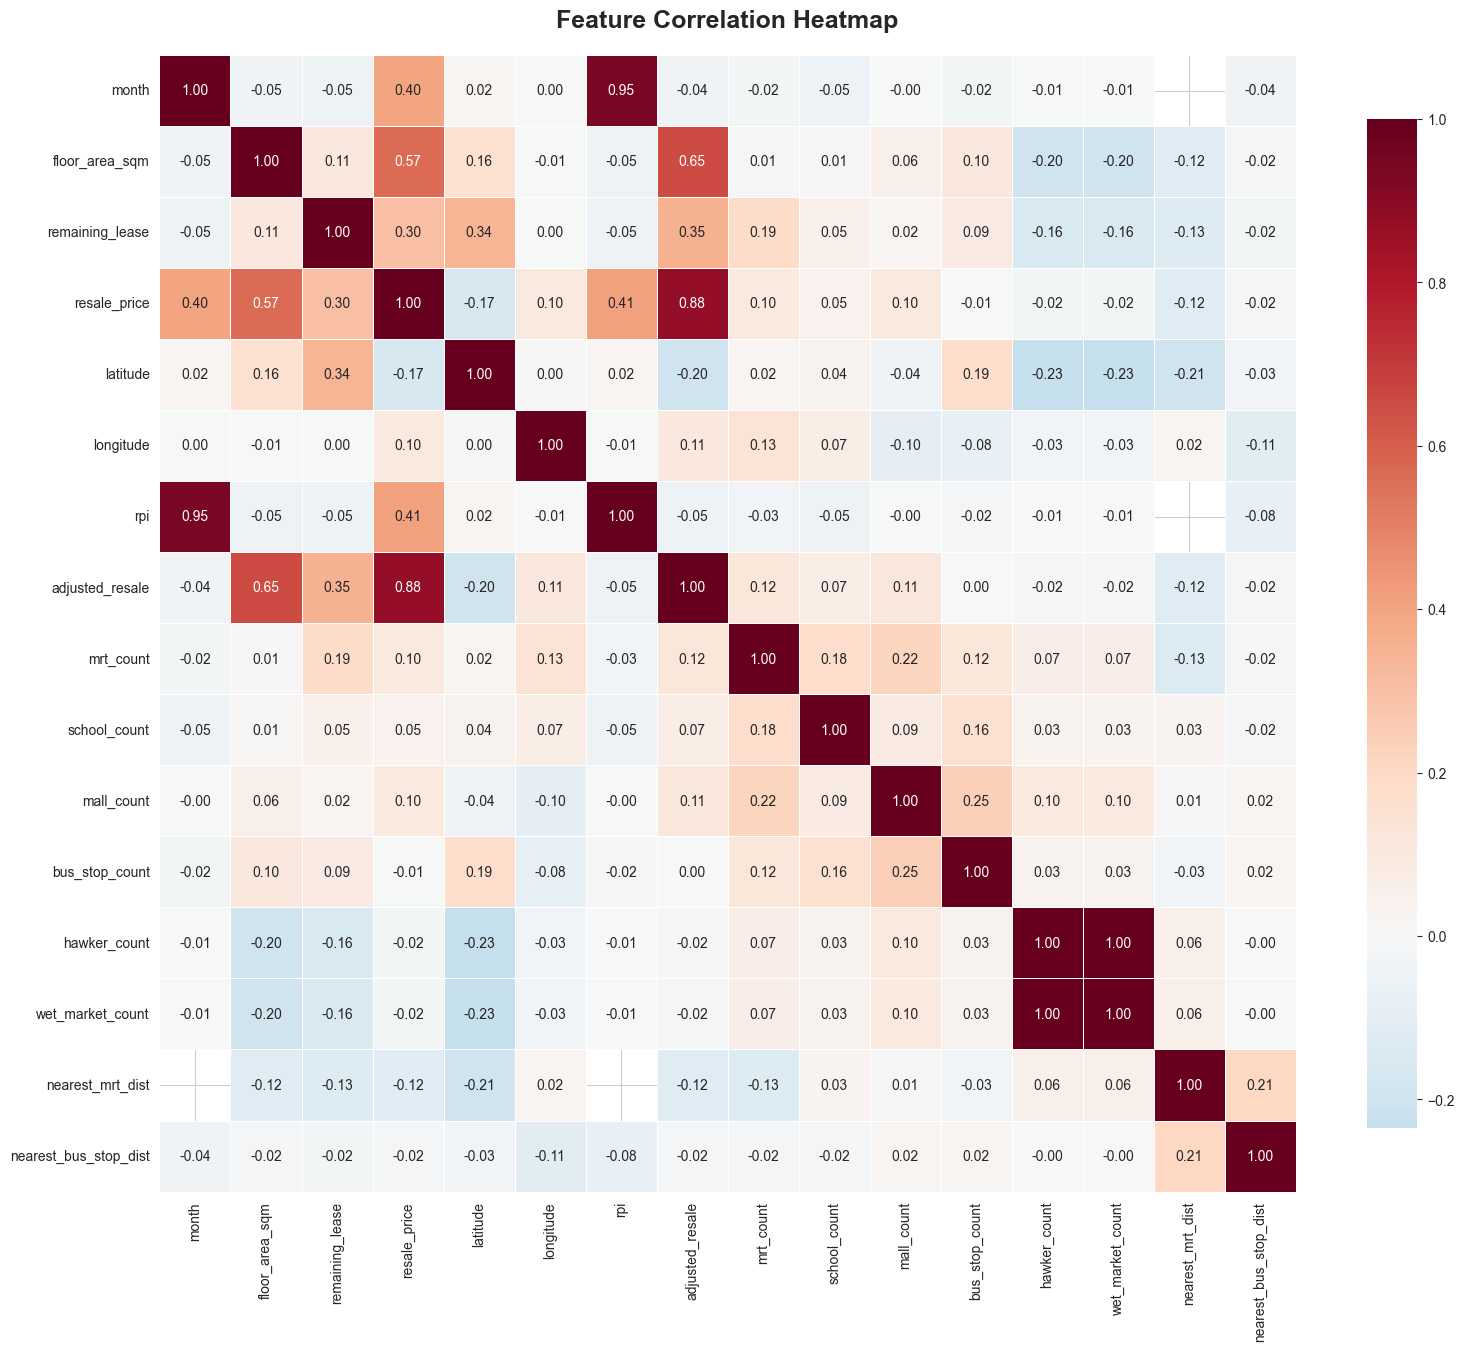

✓ Correlation heatmap generated


In [ ]:
# Get numeric columns only
numeric_cols = resale.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_cols)} numeric features\n")

# Calculate correlation matrix
correlation_matrix = resale[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap generated")

# Price Prediction Models

## Load data

In [31]:
import pandas as pd

resale = pd.read_csv("Data/processed.csv")
resale.head()

,month,town,flat_type,floor_area_sqm,remaining_lease,resale_price,latitude,longitude,storey_type_lower,storey_type_middle,...,rpi,adjusted_resale,mrt_count,school_count,mall_count,bus_stop_count,hawker_count,wet_market_count,nearest_mrt_dist,nearest_bus_stop_dist
0,0,ANG MO KIO,2 ROOM,44.0,736,232000.0,1.362005,103.853880,False,False,...,133.9,173263.629574,0,3,0,14,1,1,1016,91
1,0,ANG MO KIO,3 ROOM,67.0,727,250000.0,1.370966,103.838202,True,False,...,133.9,186706.497386,1,2,0,11,1,1,202,164
2,0,ANG MO KIO,3 ROOM,67.0,749,262000.0,1.380709,103.835368,True,False,...,133.9,195668.409261,1,0,0,12,0,0,460,136
3,0,ANG MO KIO,3 ROOM,68.0,745,265000.0,1.366201,103.857201,False,True,...,133.9,197908.887229,0,1,0,10,2,2,828,68
4,0,ANG MO KIO,3 ROOM,67.0,749,265000.0,1.381041,103.835132,True,False,...,133.9,197908.887229,1,0,0,11,0,0,433,146


In [38]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate features and target
resale = resale.dropna(subset=["nearest_mrt_dist", "nearest_bus_stop_dist"])
X = resale.drop(columns=['floor_area_sqm', 'adjusted_resale','resale_price', 'latitude', 'longitude', 'month', 'rpi'])
y = resale["adjusted_resale"]

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Create 5 bins based on price distribution  (low, medium, high for 3 bins)
y_binned = pd.qcut(y, q=5, labels=False)

# First split: Train (60%) and Temp (40%)
X_train, X_temp, y_train, y_temp, yb_train, yb_temp = train_test_split(
    X, y, y_binned,
    test_size=0.4,
    stratify=y_binned,
    random_state=42
)

# Second split: Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=yb_temp,
    random_state=42
)


# Check sizes
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (133244, 43)
Validation set: (44415, 43)
Test set: (44415, 43)


## Dummy Regressor

In [39]:
# Initialize dummy model (predicts mean of y_train)
dummy_model = DummyRegressor(strategy="mean")

# Train
dummy_model.fit(X_train, y_train)

# Predict on test set
dummy_pred = dummy_model.predict(X_test)

# Evaluate
print("Dummy Baseline Performance:")
print("MAE:", mean_absolute_error(y_test, dummy_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dummy_pred)))
print("R2:", r2_score(y_test, dummy_pred))

Dummy Baseline Performance:
MAE: 82942.71651181008
RMSE: 107742.7024975056
R2: -9.20151888328391e-06


## Linear Regression

In [43]:
# Initialize model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
print("Linear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_r2, lr_mae, lr_rmse = [], [], []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lr_cv = LinearRegression()
    lr_cv.fit(X_tr, y_tr)
    pred = lr_cv.predict(X_val)

    lr_r2.append(r2_score(y_val, pred))
    lr_mae.append(mean_absolute_error(y_val, pred))
    lr_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))

print("\nLinear Regression Cross Validation Results")
print("Mean R2:", np.mean(lr_r2))
print("Std R2:", np.std(lr_r2))
print("Mean MAE:", np.mean(lr_mae))
print("Mean RMSE:", np.mean(lr_rmse))

Linear Regression Performance:
MAE: 34454.61334769907
RMSE: 45820.668547703775
R2: 0.819136425526156

Linear Regression Cross Validation Results
Mean R2: 0.8165616252767538
Std R2: 0.0011447742704004996
Mean MAE: 34752.34348724194
Mean RMSE: 46337.547345288374


## Random Forest

In [44]:
# Init the RF model
rf_model = RandomForestRegressor(random_state=1)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
print("Random Forest Performance:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_r2, rf_mae, rf_rmse = [], [], []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf_cv = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr, y_tr)
    pred = rf_cv.predict(X_val)

    rf_r2.append(r2_score(y_val, pred))
    rf_mae.append(mean_absolute_error(y_val, pred))
    rf_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))

print("\nRandom Forest Cross Validation Results")
print("Mean R2:", np.mean(rf_r2))
print("Std R2:", np.std(rf_r2))
print("Mean MAE:", np.mean(rf_mae))
print("Mean RMSE:", np.mean(rf_rmse))

Random Forest Performance:
MAE: 15374.51161079433
RMSE: 22314.332689973864
R2: 0.9571060467281475

Random Forest Cross Validation Results
Mean R2: 0.9556858455251694
Std R2: 0.0013587472343833072
Mean MAE: 15705.298992434566
Mean RMSE: 22771.37220527402


# Controlled Ablations & Tuning

# RPI

In [3]:
rpi = pd.read_csv('Data/2025-RPI.csv')
avg_rpi = rpi['rpi'].diff().mean()
print(avg_rpi)

1.5462686567164179
